# Imports

Treasury: DGS10
S&P500: SP500
Bitcoin: Close

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import uniform_filter1d

from statsmodels.tsa.stattools import adfuller, acf, pacf

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

# Optional if installed
try:
    from arch import arch_model
    ARCH_AVAILABLE = True
except Exception:
    ARCH_AVAILABLE = False

# Optional for deep models
try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import TCN, Autoformer
    from neuralforecast.losses.pytorch import MAE
    NF_AVAILABLE = True
except Exception:
    NF_AVAILABLE = False

2026-03-13 00:02:42,161	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-03-13 00:02:42,296	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
# ============================================================
# 1. Data loading
# ============================================================
def load_data(name, start_date='2021-01-01'):
    if name == "BTC":
        bitcoin_close = "bitcoin_close.csv"
        data = pd.read_csv(f'./data/processed/{bitcoin_close}', parse_dates=["date"])
        data["btc_close"] = pd.to_numeric(data["btc_close"], errors="coerce")
        data = data.dropna(subset=["date", "btc_close"])
        data = data.drop_duplicates(subset=["date"])
        data = data.sort_values("date")
        data = data[data["date"] >= pd.to_datetime(start_date)]
        data = pd.Series(data['btc_close'].values, index=data['date'])

    elif name == "SP500":
        SP500 = "sp500_cleaned.csv"
        data = pd.read_csv(f'./data/processed/{SP500}', parse_dates=["date"])
        data["sp500"] = pd.to_numeric(data["sp500"], errors="coerce")
        data = data.dropna(subset=["date", "sp500"])
        data = data.drop_duplicates(subset=["date"])
        data = data.sort_values("date")
        data = data[data["date"] >= pd.to_datetime(start_date)]
        data = pd.Series(data['sp500'].values, index=data['date'])

    elif name == "FRED":
        FRED = "treasury_dgs10.csv"
        data = pd.read_csv(f'./data/processed/{FRED}', parse_dates=["date"])
        data["dgs10"] = pd.to_numeric(data["dgs10"], errors="coerce")
        data = data.dropna(subset=["date", "dgs10"])
        data = data.drop_duplicates(subset=["date"])
        data = data.sort_values("date")
        data = data[data["date"] >= pd.to_datetime(start_date)]
        data = pd.Series(data['dgs10'].values, index=data['date'])

    else:
        raise ValueError("Unsupported dataset name. Use 'BTC', 'SP500', or 'FRED'.")

    return data


# ============================================================
# 2. Helper functions
# ============================================================
def train_test_split_ts(series, test_size=0.2):
    n = len(series)
    split_idx = int(n * (1 - test_size))
    train = series.iloc[:split_idx].copy()
    test = series.iloc[split_idx:].copy()
    return train, test

def accuracy_metrics(y_true, y_pred, label="Model"):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-8, y_true))) * 100
    bias = np.mean(y_pred - y_true)
    pm = np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2)
    
    print(f"{label} MSE:   {mse:.4f}")
    print(f"{label} RMSE:  {rmse:.4f}")
    print(f"{label} MAE:   {mae:.4f}")
    print(f"{label} MAPE:  {mape:.4f}%")
    print(f"{label} Bias:  {bias:.4f}")
    print(f"{label} PM:    {pm:.4f}")
    print()

    return {
        "Model": label,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "Bias": bias,
        "PM": pm
    }

def rolling_mean_vol(series, window=30):
    values = np.asarray(series, dtype=float)

    roll_mean = uniform_filter1d(values, size=window, mode="nearest")

    sq_mean = uniform_filter1d(values**2, size=window, mode="nearest")
    roll_var = sq_mean - roll_mean**2
    roll_var = np.maximum(roll_var, 0)
    roll_std = np.sqrt(roll_var)

    out = pd.DataFrame(index=series.index)
    out["value"] = series
    out["roll_mean"] = roll_mean
    out["roll_std"] = roll_std
    return out

def horizonwise_errors(y_true_mat, y_pred_mat):
    """
    y_true_mat, y_pred_mat: arrays shape (n_windows, h)
    """
    h = y_true_mat.shape[1]
    rows = []
    for j in range(h):
        err = y_pred_mat[:, j] - y_true_mat[:, j]
        rows.append({
            "horizon": j + 1,
            "bias": np.mean(err),
            "var_error": np.var(err),
            "mae": np.mean(np.abs(err)),
            "rmse": np.sqrt(np.mean(err ** 2))
        })
    return pd.DataFrame(rows)

# ============================================================
# Choose differencing systematically
# ============================================================

def select_d_by_adf(series, max_d=2, alpha=0.05):
    results = []

    for d in range(max_d + 1):
        if d == 0:
            s = series.dropna()
        else:
            s = series.copy()
            for _ in range(d):
                s = s.diff()
            s = s.dropna()

        adf_res = adfuller(s, autolag="AIC")
        pval = adf_res[1]

        results.append({
            "d": d,
            "adf_stat": adf_res[0],
            "pvalue": pval
        })

        if pval < alpha:
            print(f"Selected d = {d} based on ADF p-value = {pval:.4f}")
            return d, pd.DataFrame(results)

    print(f"No differencing level up to max_d={max_d} passed ADF at alpha={alpha}. Using d={max_d}.")
    return max_d, pd.DataFrame(results)

# ============================================================
# ARIMA Model Estimation
# ============================================================

def fit_arima(train_series, order):
    
    model = ARIMA(train_series, order=order)
    result = model.fit()
    
    print(result.summary())
    
    return result

# ============================================================
# SARIMA Model Estimation
# ============================================================

def fit_sarima(train_series, order, seasonal_order):
    
    model = SARIMAX(
        train_series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    
    result = model.fit()
    
    print(result.summary())
    
    return result

# ============================================================
# Forecast Function
# ============================================================

def forecast_model(model_fit, train_series, test_series, alpha=0.05):
    
    forecast_res = model_fit.get_forecast(steps=len(test_series))
    forecast = pd.Series(
        forecast_res.predicted_mean.to_numpy(),
        index=test_series.index
    )
    # forecast = forecast_res.predicted_mean
    conf_int = forecast_res.conf_int(alpha=alpha)
    conf_int = pd.DataFrame(
        conf_int.to_numpy(),
        index=test_series.index,
        columns=["lower", "upper"]
    )
    
    # forecast = pd.Series(forecast, index=test_series.index)
    # conf_int.index = test_series.index
    
    accuracy_metrics(test_series, forecast, label="Forecast")
    
    plt.figure(figsize=(12,4))
    plt.plot(train_series, label="Train")
    plt.plot(test_series, label="Test")
    plt.plot(forecast, label="Forecast", color="C2")
    
    plt.fill_between(
        test_series.index,
        conf_int.iloc[:, 0],
        conf_int.iloc[:, 1],
        color="C2",
        alpha=0.2,
        label=f"{int((1-alpha)*100)}% Confidence Interval"
    )
    
    plt.title("Forecast vs True Values")
    plt.legend()
    plt.show()
    
    return forecast

# ============================================================
# Residual Diagnostics
# ============================================================

def residual_diagnostics(model_fit):

    resid = model_fit.resid
    
    plt.figure(figsize=(12,4))
    plt.plot(resid)
    plt.title("Model Residuals")
    plt.show()
    
    
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    plot_acf(resid, lags=40, ax=axes[0])
    plot_pacf(resid, lags=40, ax=axes[1])
    axes[0].set_title("ACF of Residuals")
    axes[1].set_title("PACF of Residuals")
    plt.show()
    
    
    lb = acorr_ljungbox(resid, lags=[10,20,40], return_df=True)
    
    print("\nLjung-Box Test on Residuals:")
    print(lb)

In [3]:
DATA_SET = "FRED"  # "BTC", "SP500", or "FRED"
df = load_data(DATA_SET)
df_orig = df.copy()  # Keep original for later use
scaler = StandardScaler()
df_scaled = pd.Series(
    scaler.fit_transform(df.values.reshape(-1,1)).flatten(),
    index=df.index
)

# EDA

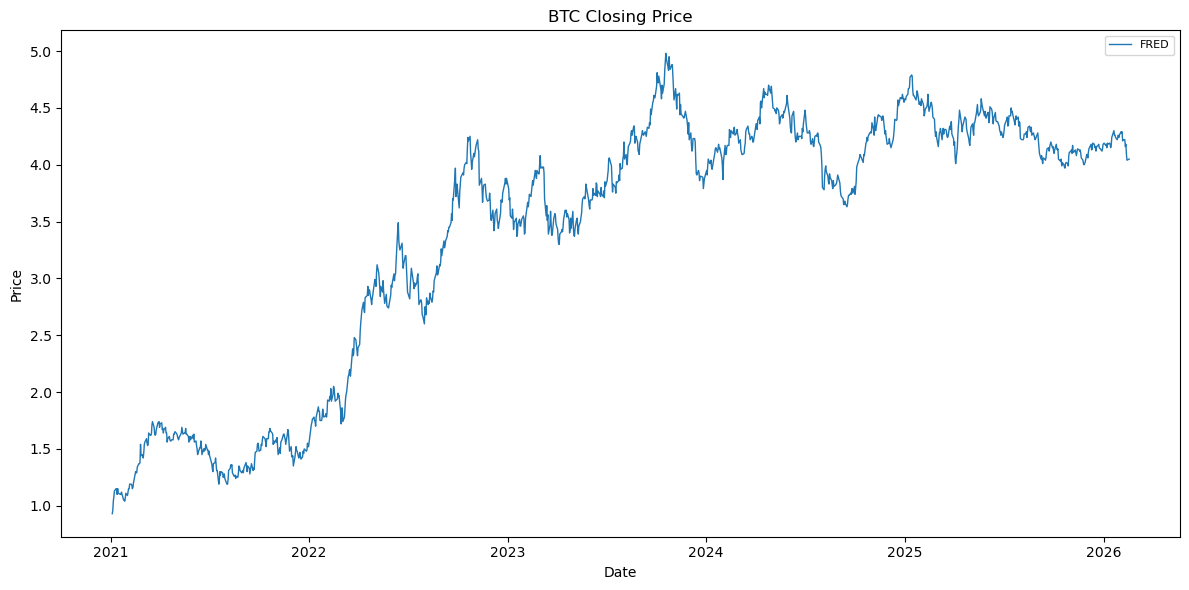

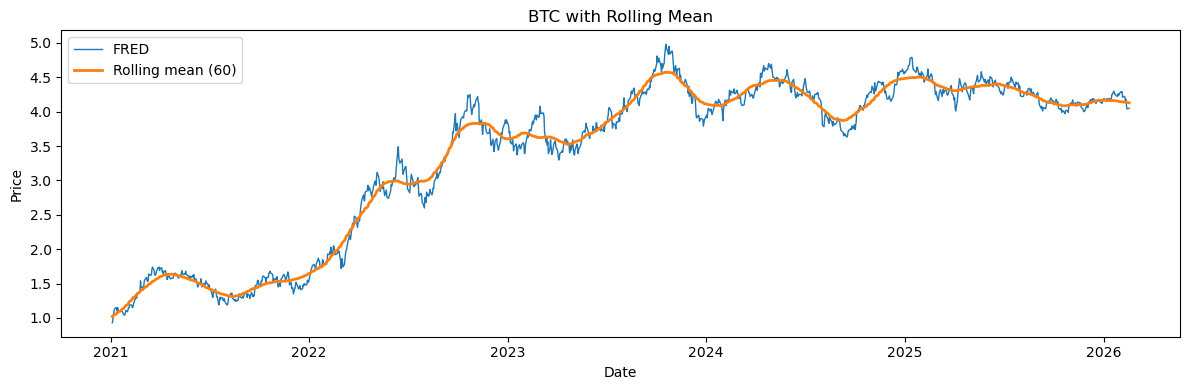

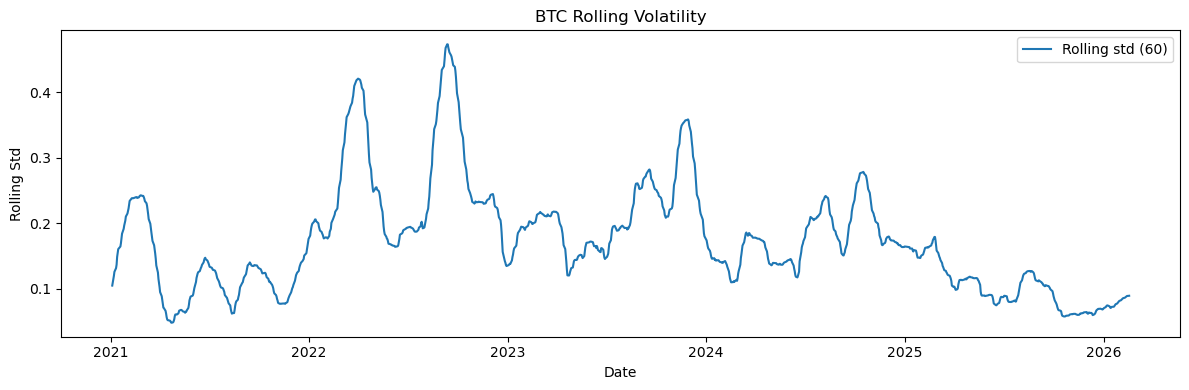

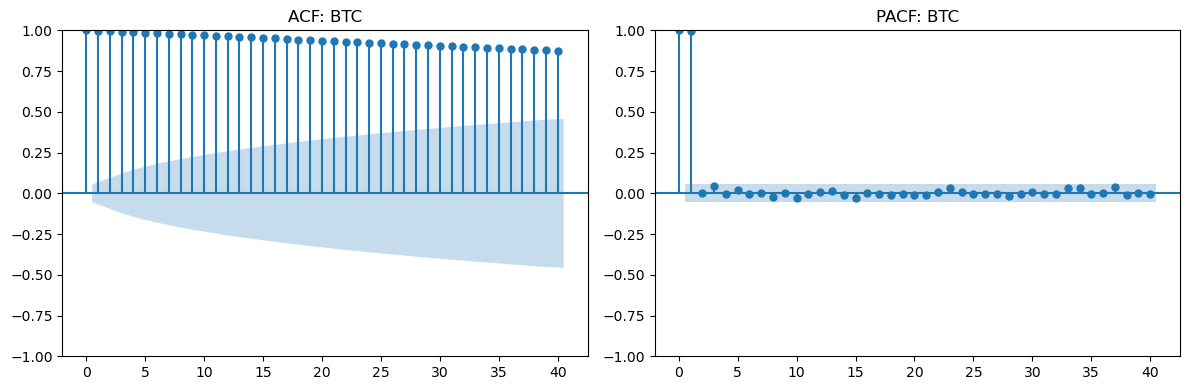

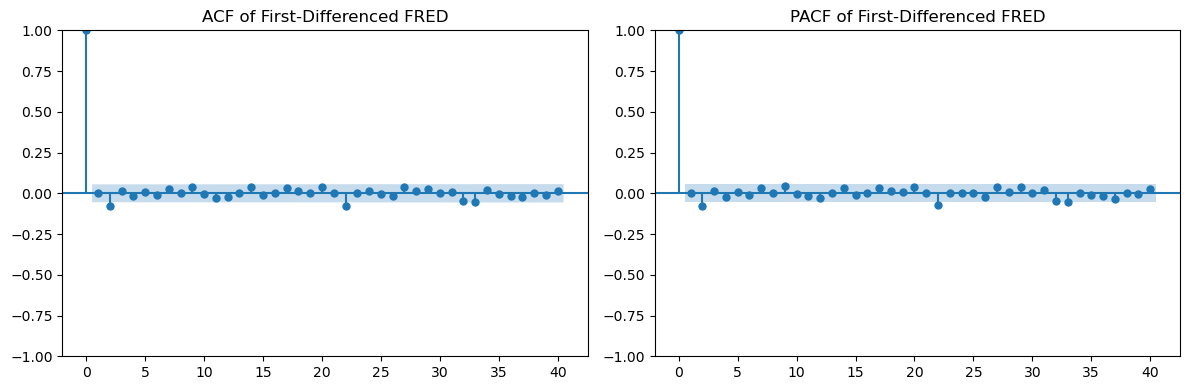

ADF on level:
{'stat': np.float64(-1.9363153260080366), 'pvalue': np.float64(0.3151747320022511)}
ADF on first difference:
{'stat': np.float64(-6.968443455710428), 'pvalue': np.float64(8.790706222918008e-10)}


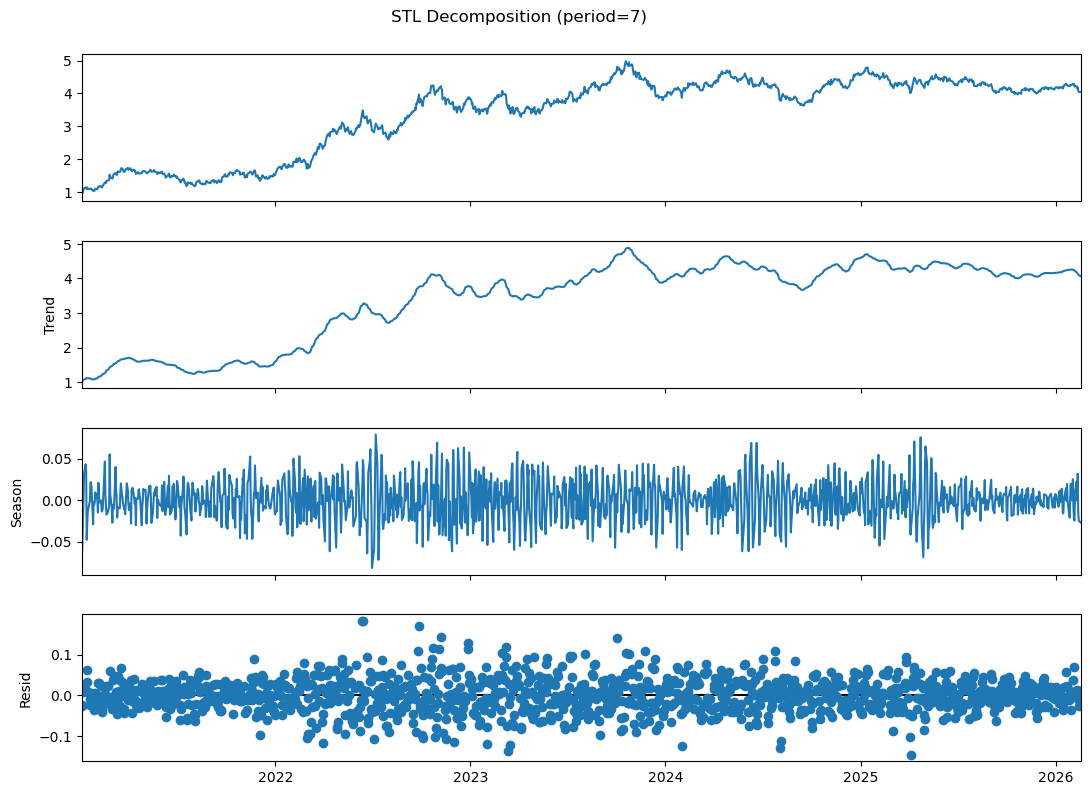

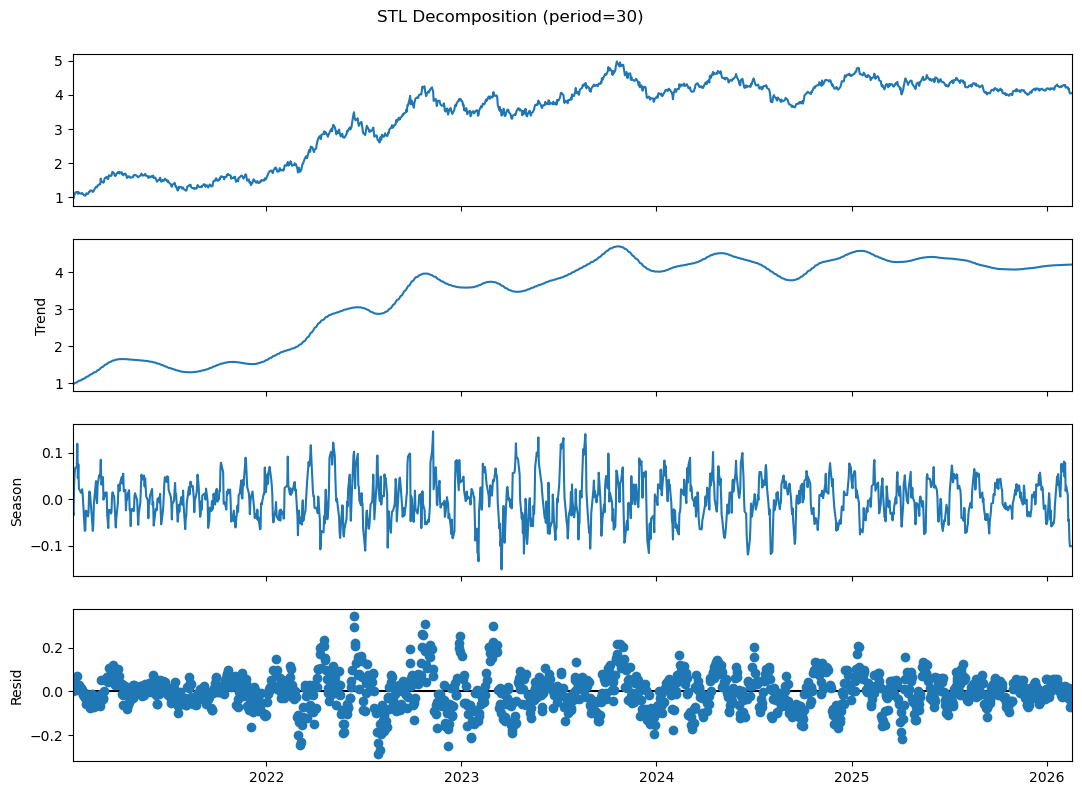

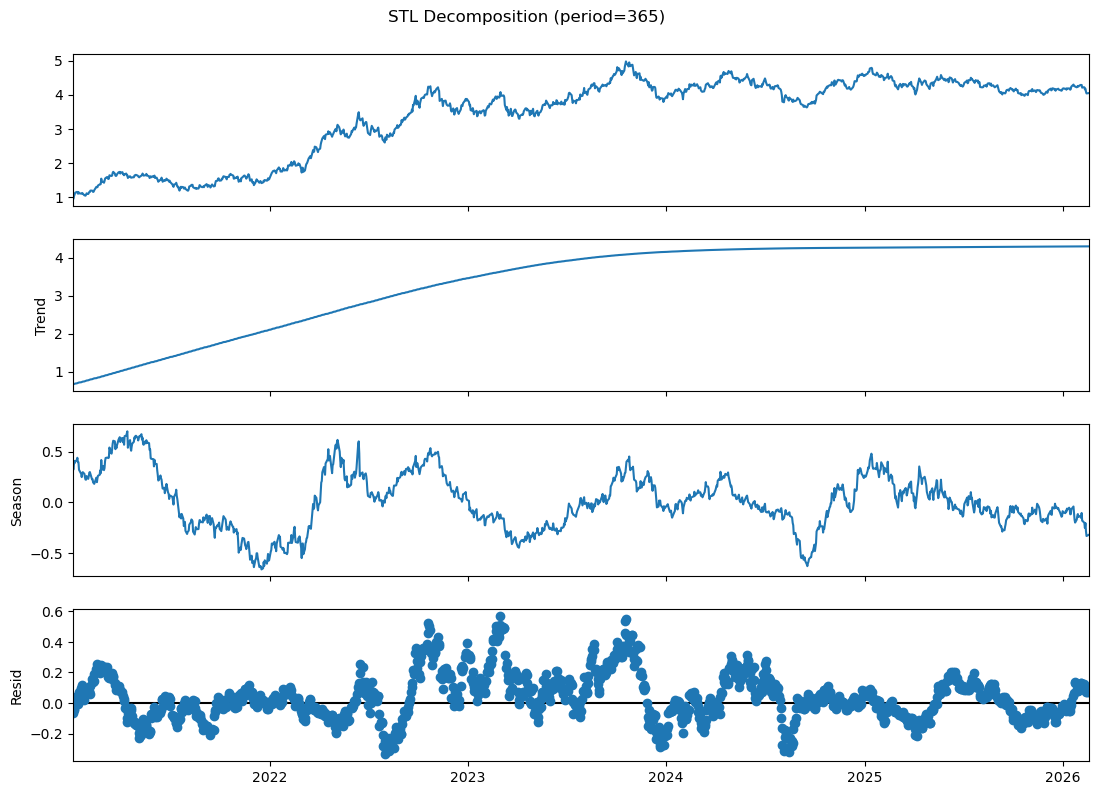

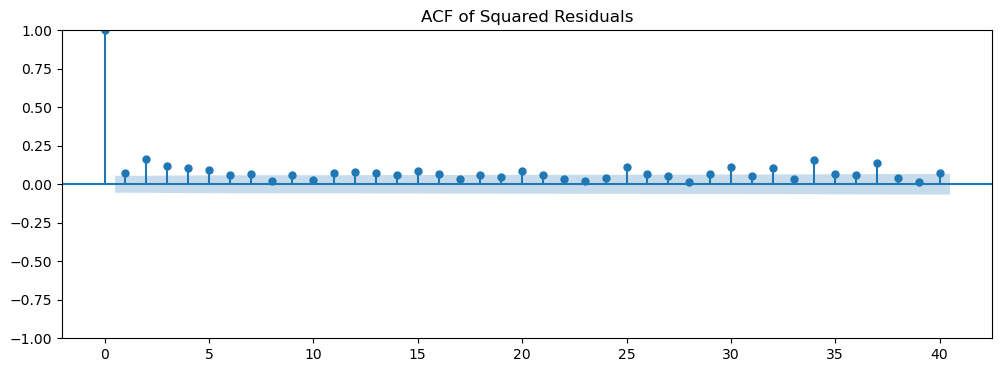


Ljung-Box Test:
      lb_stat  lb_pvalue
10  11.574607   0.314534
20  19.182332   0.510004
40  39.171756   0.507378


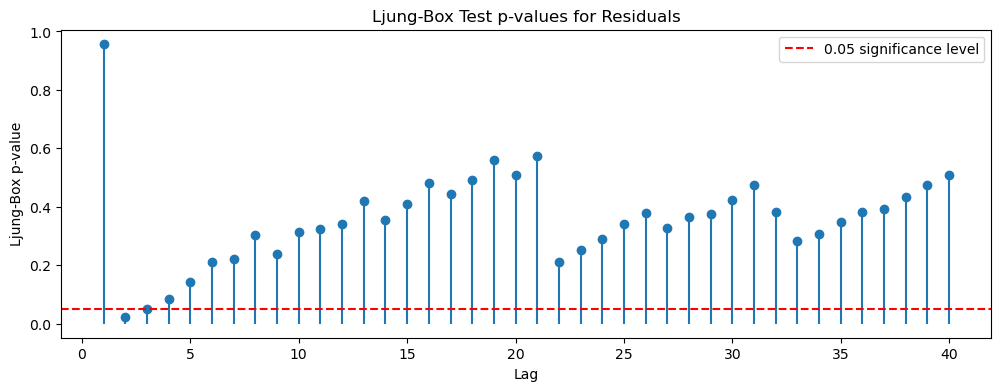

In [4]:
# plt.figure(figsize=(12, 6))
# plt.plot(df_orig, label=DATA_SET, linewidth=1)
# plt.title("BTC Closing Price")
# plt.xlabel("Date")
# plt.ylabel("Price")
# plt.legend(ncol=3, fontsize=8)
# plt.tight_layout()
# plt.show()



plt.figure(figsize=(12, 6))
plt.plot(df, label=DATA_SET, linewidth=1)
plt.title("BTC Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()
window = 60
rmv = rolling_mean_vol(df, window=window)

plt.figure(figsize=(12, 4))
plt.plot(rmv.index, rmv["value"], label=DATA_SET, linewidth=1)
plt.plot(rmv.index, rmv["roll_mean"], label=f"Rolling mean ({window})", linewidth=2)
plt.title("BTC with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(rmv.index, rmv["roll_std"], label=f"Rolling std ({window})", linewidth=1.5)
plt.title("BTC Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Std")
plt.legend()
plt.tight_layout()
plt.show()

# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df, lags=40, ax=axes[0])
plot_pacf(df, lags=40, ax=axes[1], method="ywm")
axes[0].set_title("ACF: BTC")
axes[1].set_title("PACF: BTC")
plt.tight_layout()
plt.show()

# ============================================================
# ACF / PACF of first difference
# ============================================================

dseries = df.diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(dseries, lags=40, ax=axes[0])
plot_pacf(dseries, lags=40, ax=axes[1], method="ywm")
axes[0].set_title(f"ACF of First-Differenced {DATA_SET}")
axes[1].set_title(f"PACF of First-Differenced {DATA_SET}")
plt.tight_layout()
plt.show()

adf_level = adfuller(df.dropna(), autolag=None)
adf_diff = adfuller(dseries, autolag=None)

print("ADF on level:")
print({"stat": adf_level[0], "pvalue": adf_level[1]})
print("ADF on first difference:")
print({"stat": adf_diff[0], "pvalue": adf_diff[1]})

# ============================================================
# STL Decomposition
# ============================================================
stl_results = {}
for p in [7, 30, 365]:
    stl = STL(df, period=p)
    res = stl.fit()
    stl_results[p] = {
        "trend": res.trend,
        "seasonal": res.seasonal,
        "resid": res.resid
    }
    fig = res.plot()
    fig.set_size_inches(12,8)
    plt.suptitle(f"STL Decomposition (period={p})", y=1.02)
    plt.show()
    
# ============================================================
# ACF of squared residuals (volatility clustering)
# ============================================================

fig, ax = plt.subplots(1,1,figsize=(12,4))
plot_acf(dseries**2, lags=40, ax=ax)
ax.set_title("ACF of Squared Residuals")
plt.show()

# ============================================================
# Ljung-Box test for autocorrelation in residuals
# ============================================================


lb = acorr_ljungbox(dseries, lags=[10,20,40], return_df=True)
print("\nLjung-Box Test:")
print(lb)


lb_test = acorr_ljungbox(dseries, lags=40, return_df=True)
plt.figure(figsize=(12, 4))
plt.stem(lb_test.index, lb_test['lb_pvalue'], basefmt=" ")
plt.axhline(0.05, color='red', linestyle='--', label='0.05 significance level')
plt.xlabel("Lag")
plt.ylabel("Ljung-Box p-value")
plt.title("Ljung-Box Test p-values for Residuals")
plt.legend()
plt.show()

In [5]:
rows = []

for p, comp in stl_results.items():
    trend = comp["trend"]
    seasonal = comp["seasonal"]
    resid = comp["resid"]

    trend_var = np.var(trend)
    seasonal_var = np.var(seasonal)
    resid_var = np.var(resid)
    total_var = trend_var + seasonal_var + resid_var

    rows.append({
        "period": p,
        "trend_var": trend_var,
        "seasonal_var": seasonal_var,
        "resid_var": resid_var,
        "trend_share": trend_var / total_var,
        "seasonal_share": seasonal_var / total_var,
        "resid_share": resid_var / total_var
    })

decomp_summary = pd.DataFrame(rows)

print("\nSTL Decomposition Summary\n")
decomp_summary.round(4)


STL Decomposition Summary



,period,trend_var,seasonal_var,resid_var,trend_share,seasonal_share,resid_share
0,7,1.3007,0.0006,0.0017,0.9983,0.0005,0.0013
1,30,1.2869,0.0020,0.0066,0.9934,0.0015,0.0051
2,365,1.2823,0.0762,0.0223,0.9287,0.0552,0.0161


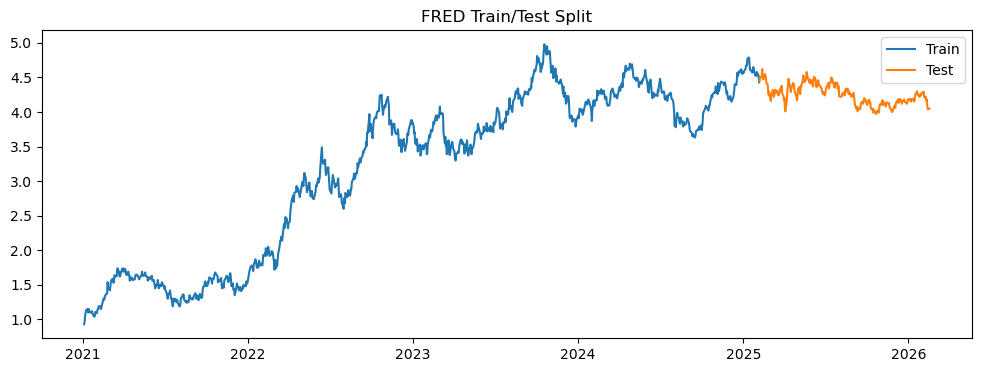

In [6]:
# ============================================================
# Train / Test Split
# ============================================================

train, test = train_test_split_ts(df, test_size=0.2)

plt.figure(figsize=(12,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.title(f"{DATA_SET} Train/Test Split")
plt.legend()
plt.show()



In [7]:
# ============================================================
# Complete ARIMA Workflow
# ============================================================

def run_arima_pipeline(train, test, p_values=range(0,4), q_values=range(0,4)):
    d_selected, d_table = select_d_by_adf(train, max_d=2)

    results, best_order = arima_grid_search(
        train_series=train,
        p_values=p_values,
        d_values=[d_selected],
        q_values=q_values,
        criterion="aicc"
    )

    fit = fit_arima(train, best_order)
    forecast = forecast_model(fit, train, test)
    residual_diagnostics(fit)

    return fit, forecast

# ============================================================
# SARIMA Pipeline
# ============================================================

def run_sarima_pipeline(train, test, order=(1,1,1), seasonal_order=(1,0,1,7)):
    
    print("----- SARIMA MODEL -----")
    
    sarima_fit = fit_sarima(train, order, seasonal_order)
    
    forecast = forecast_model(sarima_fit, train, test)
    
    residual_diagnostics(sarima_fit)
    
    return sarima_fit, forecast

# ============================================================
# Rolling Forecast Evaluation
# ============================================================

def rolling_arima_forecast(series, order=(2,1,2), horizon=20, window=200):
    
    y_true = []
    y_pred = []
    
    for i in range(window, len(series)-horizon):
        
        train = series.iloc[:i]
        test = series.iloc[i:i+horizon]
        
        model = ARIMA(train, order=order).fit()
        
        forecast = model.forecast(steps=horizon)
        
        y_true.append(test.values)
        y_pred.append(forecast.values)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    return horizonwise_errors(y_true, y_pred)

# ============================================================
# Rolling forecast evaluation for SARIMA
# ============================================================

def rolling_sarima_forecast(series, order=(1,1,1), seasonal_order=(1,0,1,7), horizon=20, window=200):
    
    y_true = []
    y_pred = []
    
    for i in range(window, len(series) - horizon):
        
        train = series.iloc[:i]
        test = series.iloc[i:i+horizon]
        
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        
        forecast = model.forecast(steps=horizon)
        
        y_true.append(test.values)
        y_pred.append(forecast.values)
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    return horizonwise_errors(y_true, y_pred)

# ============================================================
# ARIMA order selection by AICc
# ============================================================

def arima_grid_search(train_series, p_values, d_values, q_values, criterion="aic"):
    rows = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                try:
                    fit = ARIMA(train_series, order=(p, d, q)).fit()
                    k = fit.params.shape[0]
                    n = len(train_series)
                    aicc = fit.aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf

                    rows.append({
                        "p": p,
                        "d": d,
                        "q": q,
                        "aicc": aicc
                    })
                except Exception:
                    continue

    results = pd.DataFrame(rows)

    if results.empty:
        raise ValueError("No ARIMA models were successfully fit.")

    results = results.sort_values(by=criterion).reset_index(drop=True)
    best_order = tuple(results.loc[0, ["p", "d", "q"]].astype(int))

    return results, best_order

# ============================================================
# SARIMA order selection by AICc
# ============================================================

def sarima_grid_search(train_series,
                       p_values, d_values, q_values,
                       P_values, D_values, Q_values,
                       seasonal_period,
                       criterion="aicc"):
    rows = []

    for p in p_values:
        for d in d_values:
            for q in q_values:
                for P in P_values:
                    for D in D_values:
                        for Q in Q_values:
                            try:
                                fit = SARIMAX(
                                    train_series,
                                    order=(p, d, q),
                                    seasonal_order=(P, D, Q, seasonal_period),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False
                                ).fit(disp=False)
                                k = fit.params.shape[0]
                                n = len(train_series)
                                aicc = fit.aic + (2 * k * (k + 1)) / (n - k - 1) if (n - k - 1) > 0 else np.inf

                                rows.append({
                                    "p": p, "d": d, "q": q,
                                    "P": P, "D": D, "Q": Q,
                                    "s": seasonal_period,
                                    "aicc": aicc
                                })
                            except Exception:
                                continue

    results = pd.DataFrame(rows)

    if results.empty:
        raise ValueError("No SARIMA models were successfully fit.")

    results = results.sort_values(by=criterion).reset_index(drop=True)

    best = results.iloc[0]
    best_order = (int(best["p"]), int(best["d"]), int(best["q"]))
    best_seasonal = (int(best["P"]), int(best["D"]), int(best["Q"]), int(best["s"]))

    return results, best_order, best_seasonal

# ============================================================
# Evaluate candidate ARIMA models on test data
# ============================================================

def evaluate_arima_candidates(train_series, test_series, candidates):
    rows = []

    for order in candidates:
        try:
            fit = ARIMA(train_series, order=order).fit()
            forecast = fit.forecast(steps=len(test_series))

            mse = mean_squared_error(test_series, forecast)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(test_series, forecast)
            bias = np.mean(forecast - test_series)

            rows.append({
                "order": order,
                "aic": fit.aic,
                "bic": fit.bic,
                "rmse": rmse,
                "mae": mae,
                "bias": bias
            })
        except Exception:
            continue

    results = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    return results

In [8]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ValueWarning)
warnings.simplefilter("ignore", ConvergenceWarning)

Selected d = 1 based on ADF p-value = 0.0000
   d   adf_stat    pvalue
0  0  -1.479815  0.543472
1  1 -24.366410  0.000000
Top ARIMA candidates:
   p  d  q         aicc
0  0  1  2 -2702.662836
1  2  1  0 -2702.580475
2  0  1  0 -2701.421464
3  1  1  2 -2701.210385
4  2  1  1 -2701.121258
5  0  1  3 -2701.086192
6  3  1  0 -2700.872570
7  1  1  1 -2700.513872
8  1  1  3 -2699.706805
9  2  1  2 -2699.529008
Best ARIMA order: (0, 1, 2)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1024
Model:                 ARIMA(0, 1, 2)   Log Likelihood                1354.343
Date:                Fri, 13 Mar 2026   AIC                          -2702.686
Time:                        00:02:45   BIC                          -2687.895
Sample:                             0   HQIC                         -2697.071
                               - 1024                                         
Covariance

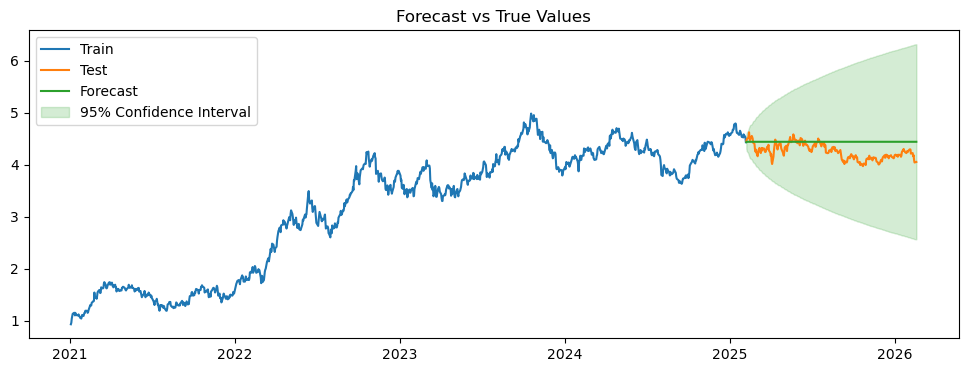

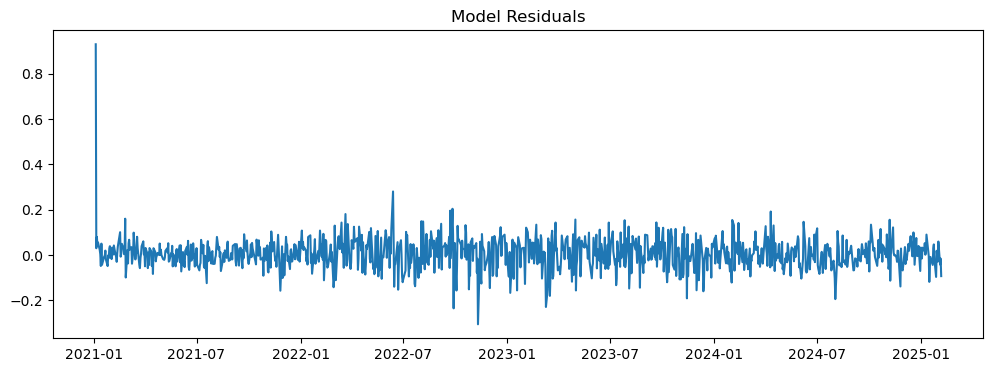

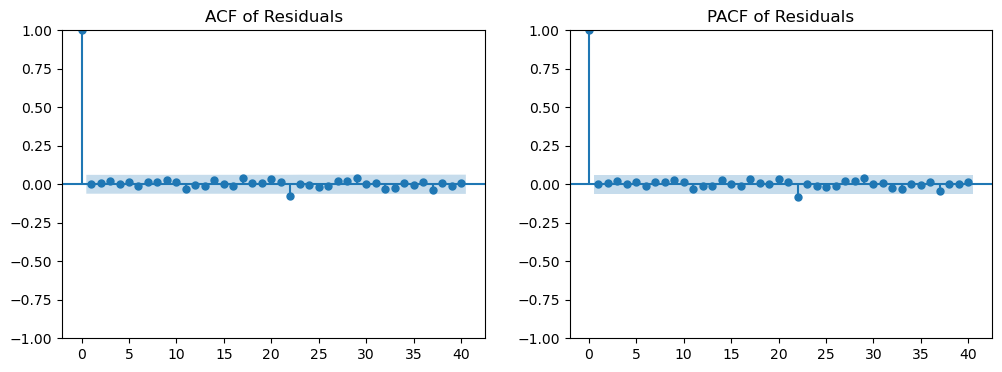


Ljung-Box Test on Residuals:
      lb_stat  lb_pvalue
10   2.394844   0.992321
20   7.188567   0.996019
40  20.687057   0.995049


In [9]:
# ============================================================
# ARIMA: choose d by ADF, then search (p,d,q), then fit best
# ============================================================

d_selected, d_table = select_d_by_adf(train, max_d=3, alpha=0.05)
print(d_table)

arima_results, best_arima_order = arima_grid_search(
    train_series=train,
    p_values=range(0, 4),
    d_values=[d_selected],
    q_values=range(0, 4),
    criterion="aicc"
)

print("Top ARIMA candidates:")
print(arima_results.head(10))
print("Best ARIMA order:", best_arima_order)

arima_fit = fit_arima(train, best_arima_order)
arima_forecast = forecast_model(arima_fit, train, test)
residual_diagnostics(arima_fit)

In [10]:
# ============================================================
# Top ARIMA candidates on test set
# ============================================================

top_arima_candidates = [
    tuple(arima_results.loc[i, ["p", "d", "q"]].astype(int))
    for i in range(min(5, len(arima_results)))
]

arima_test_compare = evaluate_arima_candidates(train, test, top_arima_candidates)

print("ARIMA candidates ranked by test RMSE:")
(arima_test_compare)

ARIMA candidates ranked by test RMSE:


,order,aic,bic,rmse,mae,bias
0,"(0, 1, 0)",-2701.425378,-2696.494883,0.228293,0.193320,NaN
1,"(2, 1, 1)",-2701.160513,-2681.438533,0.230715,0.195681,NaN
2,"(1, 1, 2)",-2701.249639,-2681.527660,0.232672,0.197576,NaN
3,"(2, 1, 0)",-2702.604004,-2687.812520,0.234232,0.199077,NaN
4,"(0, 1, 2)",-2702.686365,-2687.894881,0.234461,0.199302,NaN


Top SARIMA candidates:
   p  d  q  P  D  Q  s         aicc
0  0  1  0  0  0  0  7 -2697.995095
1  2  1  0  0  0  0  7 -2697.050808
2  1  1  0  0  0  0  7 -2695.994847
3  2  1  1  0  0  0  7 -2695.058513
4  1  1  1  0  0  0  7 -2694.468832
5  0  1  2  0  0  0  7 -2694.058425
6  0  1  1  0  0  0  7 -2693.892510
7  1  1  2  0  0  0  7 -2692.858112
8  3  1  0  0  0  0  7 -2692.129786
9  2  1  2  0  0  0  7 -2691.237676
Best SARIMA order: (0, 1, 0)
Best seasonal order: (0, 0, 0, 7)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1024
Model:               SARIMAX(0, 1, 0)   Log Likelihood                1350.000
Date:                Fri, 13 Mar 2026   AIC                          -2697.999
Time:                        00:13:50   BIC                          -2693.069
Sample:                             0   HQIC                         -2696.127
                               - 1024       

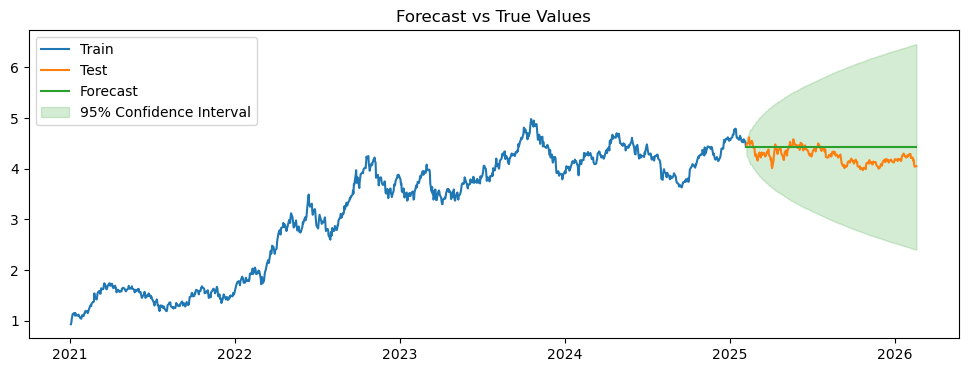

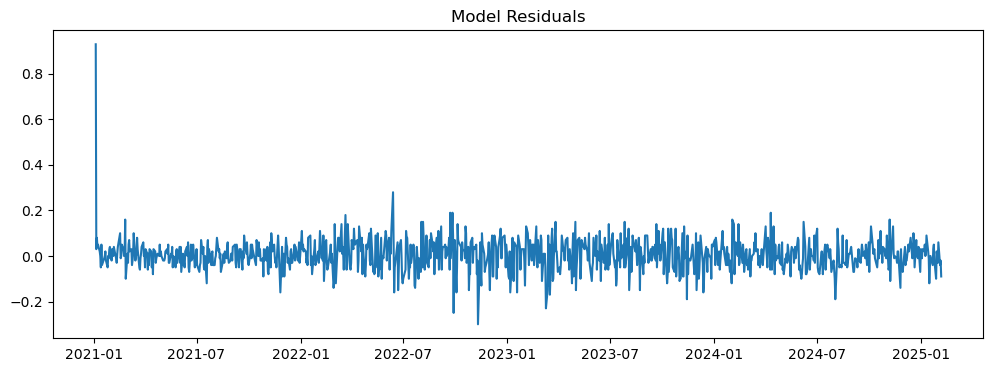

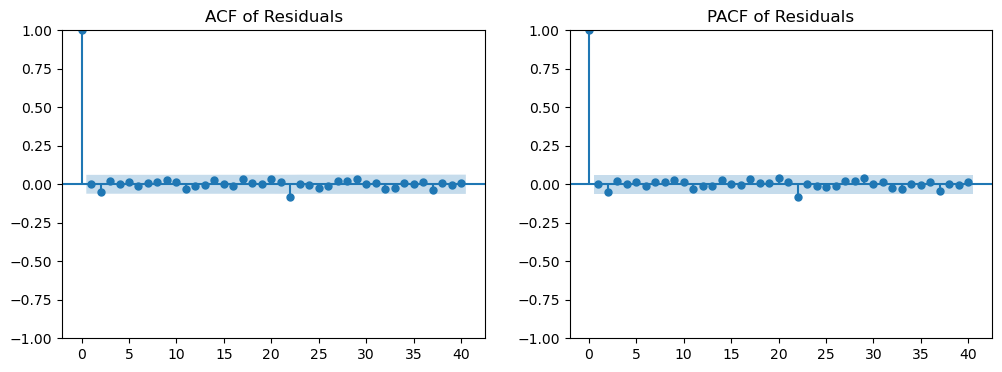


Ljung-Box Test on Residuals:
      lb_stat  lb_pvalue
10   4.407321   0.927107
20   9.677663   0.973647
40  23.326574   0.983642


In [18]:
# ============================================================
# SARIMA: only run if EDA suggests seasonality
# Try one seasonal period depending on dataset
# BTC -> 7
# SP500 -> maybe 5 or 7
# FRED -> maybe 5, 21, or skip if weak seasonality
# ============================================================

seasonal_period = 7   # change if needed

sarima_results, best_order, best_seasonal = sarima_grid_search(
    train_series=train,
    p_values=range(0, 5),
    d_values=[d_selected],
    q_values=range(0, 5),
    P_values=range(0, 2),
    D_values=[0, 1],
    Q_values=range(0, 2),
    seasonal_period=seasonal_period,
    criterion="aicc"
)

print("Top SARIMA candidates:")
print(sarima_results.head(10))
print("Best SARIMA order:", best_order)
print("Best seasonal order:", best_seasonal)

sarima_fit = fit_sarima(train, best_order, best_seasonal)
sarima_forecast = forecast_model(sarima_fit, train, test)
residual_diagnostics(sarima_fit)

In [19]:
# ============================================================
# Top SARIMA candidates on test set
# ============================================================

top_sarima_candidates = [
    (
        tuple(sarima_results.loc[i, ["p", "d", "q"]].astype(int)),
        tuple(sarima_results.loc[i, ["P", "D", "Q", "s"]].astype(int))
    )
    for i in range(min(5, len(sarima_results)))
]

rows = []

for order, seasonal_order in top_sarima_candidates:
    try:
        fit = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)

        forecast = fit.forecast(steps=len(test))

        mse = mean_squared_error(test, forecast)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(test, forecast)
        bias = np.mean(forecast - test)

        rows.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "aic": fit.aic,
            "bic": fit.bic,
            "rmse": rmse,
            "mae": mae,
            "bias": bias
        })
    except Exception:
        continue

sarima_test_compare = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)

print("SARIMA candidates ranked by test RMSE:")
sarima_test_compare

SARIMA candidates ranked by test RMSE:


,order,seasonal_order,aic,bic,rmse,mae,bias
0,"(1, 1, 1)","(0, 0, 0, 7)",-2694.492361,-2679.706748,0.226474,0.191657,NaN
1,"(0, 1, 0)","(0, 0, 0, 7)",-2697.999009,-2693.069492,0.228293,0.193320,NaN
2,"(1, 1, 0)","(0, 0, 0, 7)",-2696.006601,-2686.147567,0.228483,0.193506,NaN
3,"(2, 1, 1)","(0, 0, 0, 7)",-2695.097767,-2675.383615,0.232529,0.197436,NaN
4,"(2, 1, 0)","(0, 0, 0, 7)",-2697.074337,-2682.288723,0.234232,0.199077,NaN


    horizon      bias  var_error       mae      rmse
0         1  0.000939   0.002282  0.038715  0.047777
1         2  0.001693   0.004850  0.055152  0.069659
2         3  0.002668   0.006855  0.063857  0.082836
3         4  0.003727   0.008729  0.070331  0.093506
4         5  0.004998   0.010219  0.075920  0.101211
5         6  0.006693   0.011428  0.080023  0.107110
6         7  0.007880   0.012591  0.087593  0.112485
7         8  0.008770   0.014024  0.093998  0.118747
8         9  0.010083   0.015184  0.098528  0.123635
9        10  0.011227   0.016479  0.101836  0.128859
10       11  0.012117   0.016977  0.103416  0.130859
11       12  0.012710   0.017578  0.105526  0.133190
12       13  0.013176   0.017841  0.107237  0.134220
13       14  0.013558   0.017927  0.108142  0.134575
14       15  0.013685   0.017698  0.109295  0.133736
15       16  0.013982   0.017031  0.107602  0.131251
16       17  0.014320   0.016768  0.105489  0.130282
17       18  0.014236   0.016237  0.104081  0.

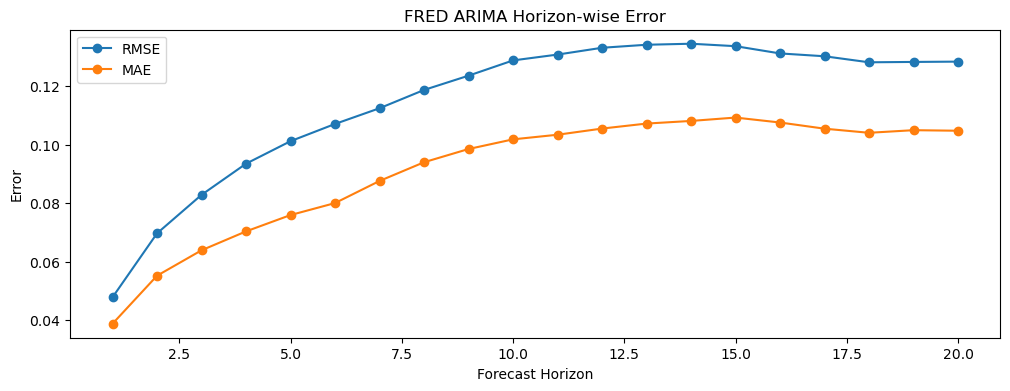

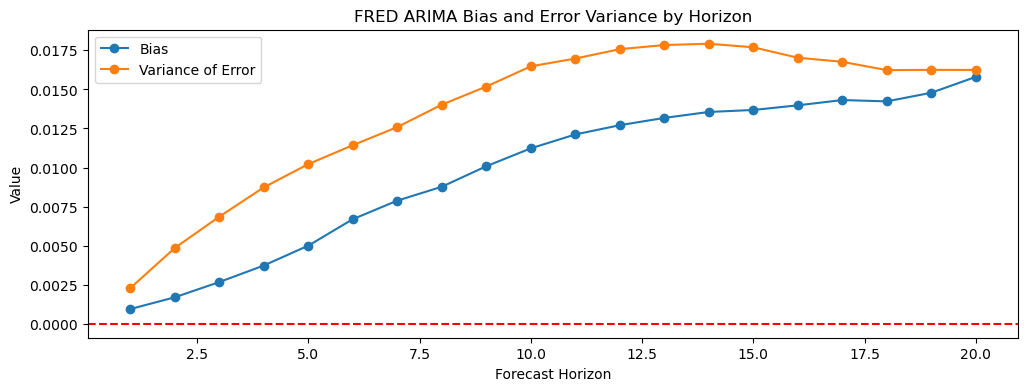

In [20]:
# ============================================================
# Rolling forecast evaluation for ARIMA
# ============================================================

rolling_arima_results = rolling_arima_forecast(
    series=df,
    order=best_arima_order,
    horizon=20,
    window=len(train)  
)

print(rolling_arima_results)

plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["rmse"], marker="o", label="RMSE")
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["mae"], marker="o", label="MAE")
plt.title(f"{DATA_SET} ARIMA Horizon-wise Error")
plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["bias"], marker="o", label="Bias")
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["var_error"], marker="o", label="Variance of Error")
plt.axhline(0, color="red", linestyle="--")
plt.title(f"{DATA_SET} ARIMA Bias and Error Variance by Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("Value")
plt.legend()
plt.show()

    horizon      bias  var_error       mae      rmse
0         1  0.000805   0.002309  0.038856  0.048060
1         2  0.001441   0.004895  0.055339  0.069982
2         3  0.002415   0.006939  0.064280  0.083334
3         4  0.003475   0.008860  0.070424  0.094191
4         5  0.004746   0.010378  0.076441  0.101985
5         6  0.006441   0.011578  0.080000  0.107794
6         7  0.007627   0.012743  0.087881  0.113141
7         8  0.008517   0.014186  0.094025  0.119407
8         9  0.009831   0.015404  0.099237  0.124502
9        10  0.010975   0.016749  0.102754  0.129881
10       11  0.011864   0.017260  0.104237  0.131912
11       12  0.012458   0.017886  0.106186  0.134319
12       13  0.012924   0.018168  0.108178  0.135407
13       14  0.013305   0.018315  0.108983  0.135984
14       15  0.013432   0.018084  0.110381  0.135147
15       16  0.013729   0.017379  0.108644  0.132544
16       17  0.014068   0.017089  0.106271  0.131481
17       18  0.013983   0.016543  0.104746  0.

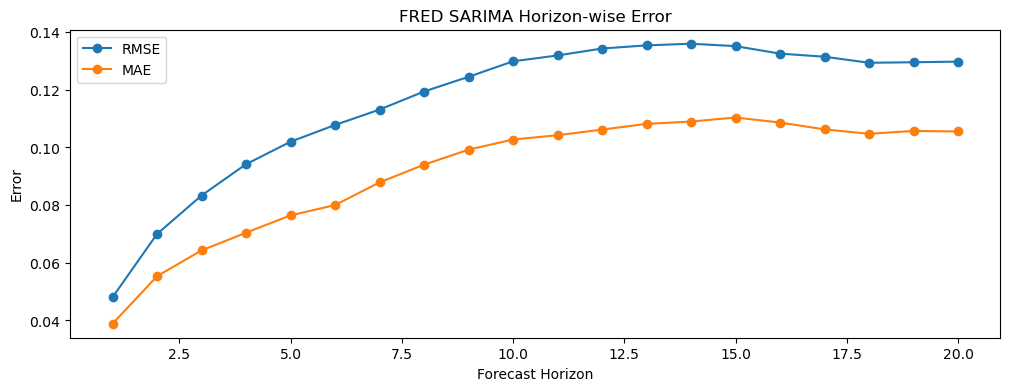

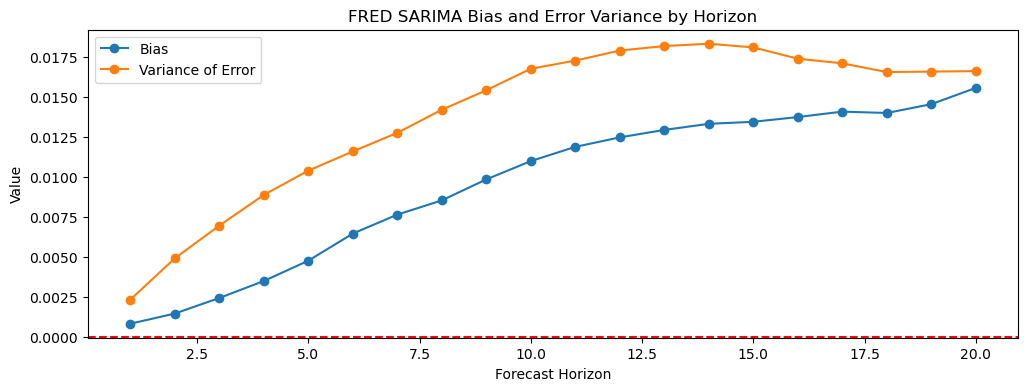

In [21]:
# ============================================================
# Rolling forecast evaluation for SARIMA
# ============================================================

rolling_sarima_results = rolling_sarima_forecast(
    series=df,
    order=best_order,
    seasonal_order=best_seasonal,
    horizon=20,
    window=len(train)
)

print(rolling_sarima_results)

plt.figure(figsize=(12,4))
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["rmse"], marker="o", label="RMSE")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["mae"], marker="o", label="MAE")
plt.title(f"{DATA_SET} SARIMA Horizon-wise Error")
plt.xlabel("Forecast Horizon")
plt.ylabel("Error")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["bias"], marker="o", label="Bias")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["var_error"], marker="o", label="Variance of Error")
plt.axhline(0, color="red", linestyle="--")
plt.title(f"{DATA_SET} SARIMA Bias and Error Variance by Horizon")
plt.xlabel("Forecast Horizon")
plt.ylabel("Value")
plt.legend()
plt.show()

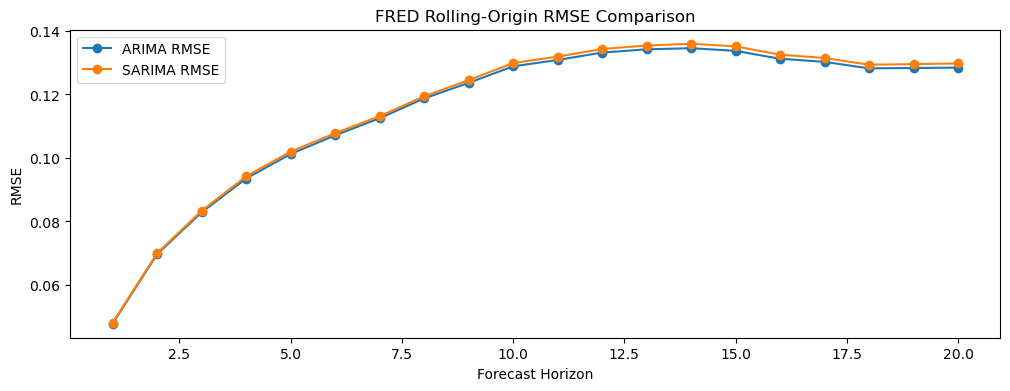

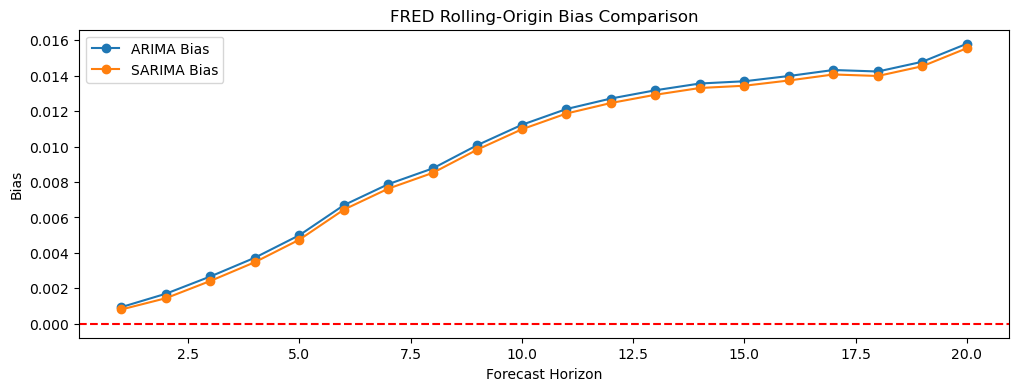

In [22]:
plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["rmse"], marker="o", label="ARIMA RMSE")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["rmse"], marker="o", label="SARIMA RMSE")
plt.title(f"{DATA_SET} Rolling-Origin RMSE Comparison")
plt.xlabel("Forecast Horizon")
plt.ylabel("RMSE")
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(rolling_arima_results["horizon"], rolling_arima_results["bias"], marker="o", label="ARIMA Bias")
plt.plot(rolling_sarima_results["horizon"], rolling_sarima_results["bias"], marker="o", label="SARIMA Bias")
plt.axhline(0, color="red", linestyle="--")
plt.title(f"{DATA_SET} Rolling-Origin Bias Comparison")
plt.xlabel("Forecast Horizon")
plt.ylabel("Bias")
plt.legend()
plt.show()

In [23]:
# ============================================================
# Simple side-by-side final comparison
# ============================================================

final_compare = pd.DataFrame([
    accuracy_metrics(test, arima_forecast, label=f"ARIMA {best_arima_order}"),
    accuracy_metrics(test, sarima_forecast, label=f"SARIMA {best_order} x {best_seasonal}")
])

final_compare

ARIMA (0, 1, 2) MSE:   0.0550
ARIMA (0, 1, 2) RMSE:  0.2345
ARIMA (0, 1, 2) MAE:   0.1993
ARIMA (0, 1, 2) MAPE:  4.7856%
ARIMA (0, 1, 2) Bias:  0.1854
ARIMA (0, 1, 2) PM:    0.0030

SARIMA (0, 1, 0) x (0, 0, 0, 7) MSE:   0.0521
SARIMA (0, 1, 0) x (0, 0, 0, 7) RMSE:  0.2283
SARIMA (0, 1, 0) x (0, 0, 0, 7) MAE:   0.1933
SARIMA (0, 1, 0) x (0, 0, 0, 7) MAPE:  4.6423%
SARIMA (0, 1, 0) x (0, 0, 0, 7) Bias:  0.1776
SARIMA (0, 1, 0) x (0, 0, 0, 7) PM:    0.0029



,Model,MSE,RMSE,MAE,MAPE,Bias,PM
0,"ARIMA (0, 1, 2)",0.054972,0.234461,0.199302,4.785589,0.185450,0.003037
1,"SARIMA (0, 1, 0) x (0, 0, 0, 7)",0.052118,0.228293,0.193320,4.642330,0.177617,0.002879
